*Aprendizaje Profundo*  
*Tarea -* Proyecto Regresion Logistica Clasficador de Habitos  
*Autores:* Cervantes Jazmin, González Daniel  
*Profesor:* Dr. Sebastian Salazar

# Clasificador de Habitos Saludables

## Cargar Librerias

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Generar Datos

In [18]:
rng = np.random.default_rng(10)
n = 250  # total de registros

# Días saludables (1)
sueño_ok = rng.normal(7.5, 0.6, n//2)
agua_ok = rng.normal(2.4, 0.4, n//2)
pasos_ok = rng.normal(9500, 1500, n//2)
comida_chatarra_ok = rng.normal(300, 150, n//2)
estres_ok = rng.normal(3.5, 1.5, n//2)
saludable = np.ones(n//2, dtype=int)

# Días no saludables (0)
sueño_bad = rng.normal(5.6, 0.8, n//2)
agua_bad = rng.normal(1.3, 0.3, n//2)
pasos_bad = rng.normal(3500, 1000, n//2)
comida_chatarra_bad = rng.normal(800, 200, n//2)
estres_bad = rng.normal(7.0, 1.5, n//2)
saludable_bad = np.zeros(n//2, dtype=int)

# Unir ambos conjuntos
X = np.concatenate([
    np.column_stack([sueño_ok, agua_ok, pasos_ok, comida_chatarra_ok, estres_ok, saludable]),
    np.column_stack([sueño_bad, agua_bad, pasos_bad, comida_chatarra_bad, estres_bad, saludable_bad])
])

Estres
| Valor    | Significado                                              |
| -------- | -------------------------------------------------------- |
| 1–2  | Día muy tranquilo, relajado.                             |
| 3–4  | Algo de tensión, pero manejable.                         |
| 5–6  | Estrés moderado (día normal de trabajo o estudio).       |
| 7–8  | Día pesado o agitado.                                    |
| 9–10 | Estrés alto: ansiedad, exceso de tareas, preocupaciones. |


In [19]:
df = pd.DataFrame(X, columns=["sueño(hr)", "agua(lt)", "pasos", "comida_chatarra(kcal)", "estres", "saludable"])
df = df.round({'sueño(hr)': 2,'agua(lt)': 2,'pasos': 0,'comida_chatarra(kcal)': 2,'estres': 0})
df.head()
#df.to_csv("habitos.csv", index=False, float_format="%.2f")

,sueño(hr),agua(lt),pasos,comida_chatarra(kcal),estres,saludable
0,6.84,2.40,10298.0,23.84,6.0,1.0
1,7.06,2.82,11547.0,238.65,2.0,1.0
2,7.03,2.05,10186.0,489.68,4.0,1.0
3,7.66,1.88,8812.0,292.67,3.0,1.0
4,7.35,1.93,6518.0,26.99,4.0,1.0


In [20]:
X = df[['sueño(hr)','agua(lt)','pasos','comida_chatarra(kcal)','estres']].to_numpy(dtype=float)
y = df['saludable'].to_numpy(dtype=int)

## Normalizacion (z-score)

In [22]:
X_mean = X.mean(axis=0, keepdims=True)
X_std  = X.std(axis=0, keepdims=True) + 1e-8
Xz = (X - X_mean) / X_std
Xz

array([[ 0.31970512,  0.99779005,  1.17521044, -1.69342564,  0.33275498],
       [ 0.51008821,  1.68053985,  1.56506322, -0.98746486, -1.33938061],
       [ 0.48412688,  0.42883189,  1.14025166, -0.16246911, -0.50331281],
       ...,
       [-1.12547557, -0.49775711, -0.95977198,  1.07237892,  0.33275498],
       [-0.87451605, -0.92041174, -0.07362943,  0.73808195, -0.08527892],
       [-0.78797828, -1.53813775, -1.09274018,  1.00405377,  2.00489057]],
      shape=(250, 5))

## Separar en entrenamiento y test

In [23]:
idx = np.arange(len(Xz))
rng.shuffle(idx)
split = int(0.8 * len(idx))
tr, te = idx[:split], idx[split:]
Xtr, ytr = Xz[tr], y[tr]
Xte, yte = Xz[te], y[te]
Xtr.shape, Xte.shape


((200, 5), (50, 5))

# Regresion Logistica

In [28]:
def sigmoid(z):
    z = np.clip(z, -40, 40)
    return 1.0 / (1.0 + np.exp(-z))

def forward(X, W, b):
    return sigmoid(X @ W + b)

def loss_logistic(y_true, y_prob, eps=1e-9):
    y_prob = np.clip(y_prob, eps, 1-eps)
    return -np.mean(y_true*np.log(y_prob) + (1-y_true)*np.log(1-y_prob))

def accuracy(y_true, y_pred_bin):
    return np.mean(y_true == y_pred_bin)

## Entrenamiento

In [ ]:
d = Xtr.shape[1]
W = np.zeros(d)      # pesos
b = 0.0              # sesgo
lr = 0.1
epochs = 1500

hist = []
for ep in range(1, epochs+1):
    yprob = forward(Xtr, W, b)
    diff = (yprob - ytr)
    gW = (Xtr.T @ diff) / len(Xtr)
    gb = np.mean(diff)
    # Actualización
    W -= lr * gW
    b -= lr * gb
    if ep % 100 == 0 or ep == 1:
        ltr = loss_logistic(ytr, yprob)
        hist.append((ep, ltr))
        print(f"[ep {ep:4d}] loss={ltr:.4f}")


[ep    1] loss=0.6931
[ep  100] loss=0.0487
[ep  200] loss=0.0280
[ep  300] loss=0.0205
[ep  400] loss=0.0165
[ep  500] loss=0.0139
[ep  600] loss=0.0122
[ep  700] loss=0.0109
[ep  800] loss=0.0099
[ep  900] loss=0.0091
[ep 1000] loss=0.0085
[ep 1100] loss=0.0080
[ep 1200] loss=0.0075
[ep 1300] loss=0.0071
[ep 1400] loss=0.0067
[ep 1500] loss=0.0064


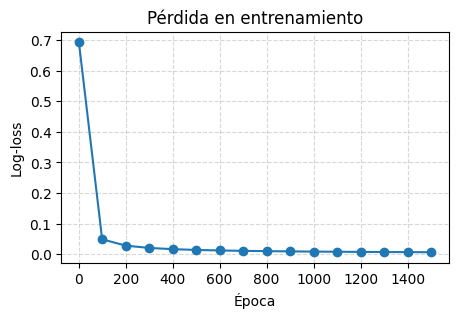

In [25]:
plt.figure(figsize=(5,3))
xs = [e for e,_ in hist]
ys = [l for _,l in hist]
plt.plot(xs, ys, marker='o')
plt.title("Pérdida en entrenamiento")
plt.xlabel("Época")
plt.ylabel("Log-loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Metricas

In [26]:
# Predicciones
yprob_te = forward(Xte, W, b)

# Umbral 0.5 por defecto
yth_te = (yprob_te >= 0.5).astype(int)

# Métricas manuales
acc = accuracy(yte, yth_te)

TP = int(np.sum((yte==1) & (yth_te==1)))
TN = int(np.sum((yte==0) & (yth_te==0)))
FP = int(np.sum((yte==0) & (yth_te==1)))
FN = int(np.sum((yte==1) & (yth_te==0)))

precision = TP / (TP + FP + 1e-9)
recall    = TP / (TP + FN + 1e-9)
f1        = 2*precision*recall / (precision + recall + 1e-9)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1       : {f1:.3f}")
print("Matriz de confusión [ [TN FP] [FN TP] ] =")
print(np.array([[TN, FP],[FN, TP]]))


Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1       : 1.000
Matriz de confusión [ [TN FP] [FN TP] ] =
[[27  0]
 [ 0 23]]


# Ejemplo

In [ ]:
# 7h de sueño, 2.1L agua, 9000 pasos, 300 cal chatarra, estrés=4
nuevo = np.array([[7.0, 2.1, 9000, 300, 4.0]], dtype=float)
nuevo_z = (nuevo - X_mean) / X_std
p_salud = forward(nuevo_z, W, b)[0]
print(f"Probabilidad de 'día saludable': {p_salud:.3f}")
print("Clase predicha:", int(p_salud >= 0.5))


Probabilidad de 'día saludable': 0.994
Clase predicha: 1
